<a href="https://colab.research.google.com/github/sanju492/exit-exam/blob/main/exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pickle


#Data Cleaning & Feature Engineering


In [9]:
df = pd.read_csv("Bengaluru_House_Data.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [22]:
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [23]:
print(df.columns)

Index(['location', 'size', 'total_sqft', 'bath', 'price'], dtype='object')


In [24]:
#Check missing values
print(df.isnull().sum())

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64


In [25]:
#Remove Missing Essential Data
df = df.dropna(
    subset=["location", "size", "total_sqft", "bath", "price"]
)

print(df.shape)

(13246, 5)


In [26]:
#Check data
df.head()


,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


# EDA & Modeling

In [39]:
print(df.columns.tolist())
print(df.dtypes)

['location', 'size', 'total_sqft', 'bath', 'price', 'bhk']
location       object
size           object
total_sqft     object
bath          float64
price         float64
bhk             int64
dtype: object


In [40]:
def convert_sqft_to_num(x):
    try:
        tokens = str(x).split("-")

        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2

        return float(x)

    except:
        return None


df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_num)

df = df.dropna(subset=["total_sqft"])

print(df["total_sqft"].dtype)

float64


/tmp/ipykernel_548/3544262101.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_num)


In [41]:
#Feature Engineering & Outlier Removal
df["price_per_sqft"] = (
    df["price"] * 100000
) / df["total_sqft"]

print(df[["price", "total_sqft", "price_per_sqft"]].head())

    price  total_sqft  price_per_sqft
0   39.07      1056.0     3699.810606
1  120.00      2600.0     4615.384615
2   62.00      1440.0     4305.555556
3   95.00      1521.0     6245.890861
4   51.00      1200.0     4250.000000


/tmp/ipykernel_548/4240515311.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_per_sqft"] = (


In [42]:
#Remove statistical outliers
mean = df["price_per_sqft"].mean()
std = df["price_per_sqft"].std()

df = df[
    (df["price_per_sqft"] >= mean - std) &
    (df["price_per_sqft"] <= mean + std)
]

print(df.shape)

(13193, 7)


In [43]:
#Group rare locations as Other
location_stats = df["location"].value_counts()

rare_locations = location_stats[
    location_stats <= 10
].index

df["location"] = df["location"].apply(
    lambda x: "Other" if x in rare_locations else x
)

print(df["location"].value_counts().head())

location
Other              2867
Whitefield          532
Sarjapur  Road      391
Electronic City     304
Kanakpura Road      264
Name: count, dtype: int64


In [44]:
#final check
print(df.columns.tolist())

['location', 'size', 'total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft']


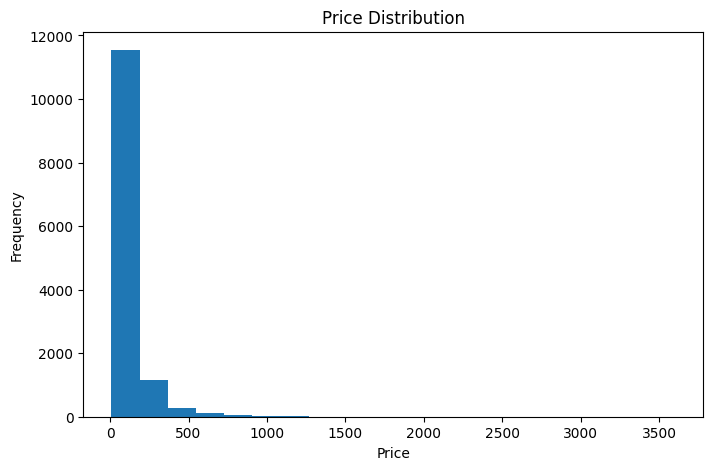

In [45]:
#Visualize Price Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=20)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")

plt.show()

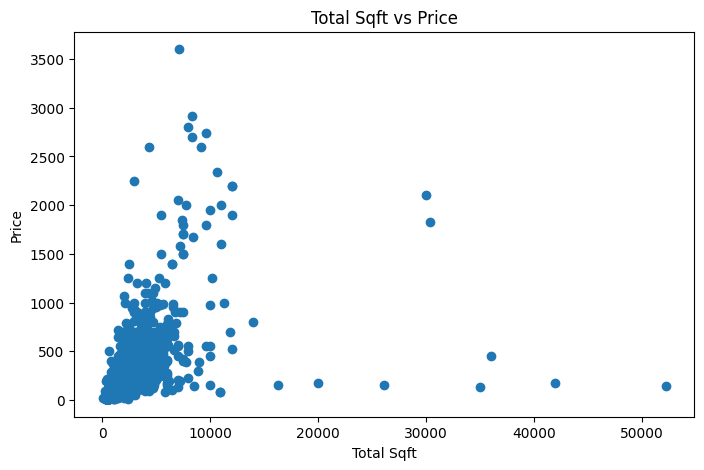

In [46]:
#Explore Price Relationships
plt.figure(figsize=(8, 5))

plt.scatter(df["total_sqft"], df["price"])

plt.xlabel("Total Sqft")
plt.ylabel("Price")
plt.title("Total Sqft vs Price")

plt.show()

In [47]:
#Build and Evaluate a Regression Model
X = df.drop(
    ["price", "size", "price_per_sqft"],
    axis=1
)

y = df["price"]

print(X.head())
print(y.head())

                   location  total_sqft  bath  bhk
0  Electronic City Phase II      1056.0   2.0    2
1          Chikka Tirupathi      2600.0   5.0    4
2               Uttarahalli      1440.0   2.0    3
3        Lingadheeranahalli      1521.0   3.0    3
4                  Kothanur      1200.0   2.0    2
0     39.07
1    120.00
2     62.00
3     95.00
4     51.00
Name: price, dtype: float64


In [48]:
#Transform Categorical Feature
X = pd.get_dummies(
    X,
    columns=["location"],
    dtype=int
)

print(X.head())
print(X.shape)

   total_sqft  bath  bhk  location_1st Block Jayanagar  \
0      1056.0   2.0    2                             0   
1      2600.0   5.0    4                             0   
2      1440.0   2.0    3                             0   
3      1521.0   3.0    3                             0   
4      1200.0   2.0    2                             0   

   location_1st Phase JP Nagar  location_2nd Phase Judicial Layout  \
0                            0                                   0   
1                            0                                   0   
2                            0                                   0   
3                            0                                   0   
4                            0                                   0   

   location_2nd Stage Nagarbhavi  location_5th Block Hbr Layout  \
0                              0                              0   
1                              0                              0   
2                            

In [49]:
#split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10554, 244)
Testing data: (2639, 244)


In [50]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [51]:
#make prediction
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 72.19129956 222.45996536 125.72013667  48.73105623  67.25038102
  69.21595126 380.05704227 101.40786181  97.20912784 293.24884045]


In [52]:
#Evaluate Using R-squared
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R-squared Score:", r2)

R-squared Score: 0.5033934743953674


# Build and Evaluate a Regression Model:


In [56]:
#prepare data
X = df.drop(
    ["price", "size", "price_per_sqft"],
    axis=1
)

y = df["price"]

print(X.columns.tolist())

['location', 'total_sqft', 'bath', 'bhk']


In [57]:
#Transform Categorical Features
X = pd.get_dummies(
    X,
    columns=["location"],
    dtype=int
)

print(X.head())
print(X.shape)

   total_sqft  bath  bhk  location_1st Block Jayanagar  \
0      1056.0   2.0    2                             0   
1      2600.0   5.0    4                             0   
2      1440.0   2.0    3                             0   
3      1521.0   3.0    3                             0   
4      1200.0   2.0    2                             0   

   location_1st Phase JP Nagar  location_2nd Phase Judicial Layout  \
0                            0                                   0   
1                            0                                   0   
2                            0                                   0   
3                            0                                   0   
4                            0                                   0   

   location_2nd Stage Nagarbhavi  location_5th Block Hbr Layout  \
0                              0                              0   
1                              0                              0   
2                            

In [58]:
#split tha data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10554, 244)
Testing data: (2639, 244)


In [59]:
#Train Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [60]:
#make predection
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 72.19129956 222.45996536 125.72013667  48.73105623  67.25038102
  69.21595126 380.05704227 101.40786181  97.20912784 293.24884045]


In [61]:
#Evaluate Using R-squared
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R-squared Score:", r2)

R-squared Score: 0.5033934743953674


In [62]:
import pickle

In [64]:
#save the traind model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


In [66]:
#Save the encoded column names
columns = X.columns.tolist()

with open("columns.pkl", "wb") as f:
    pickle.dump(columns, f)

print("Columns saved successfully")

Columns saved successfully
